<a href="https://colab.research.google.com/github/HemanthSelva/spam-classifier-nlp/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📧 Spam Classifier
**Task:** Text Preprocessing (Tokenization, Stemming, Lemmatization) → TF-IDF → Logistic Regression → Evaluation

**Dataset:** UCI SMS Spam Collection Dataset

## Step 1: Install & Import Libraries

In [16]:
# Install required libraries
!pip install nltk scikit-learn pandas numpy matplotlib seaborn

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Step 2: Load Dataset
Using the **SMS Spam Collection Dataset** from UCI. We'll load it directly via URL.

In [18]:
# Load the SMS Spam dataset
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


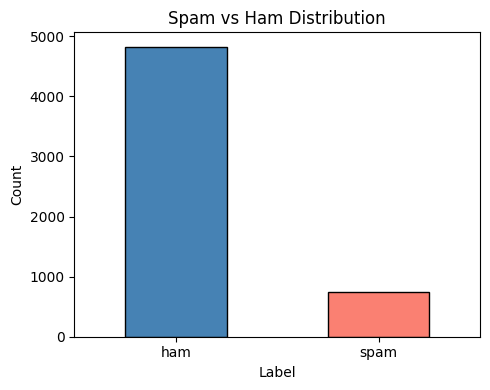

In [19]:
# Basic info
print("Label Distribution:")
print(df['label'].value_counts())

# Visualize class distribution
plt.figure(figsize=(5, 4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 3: Data Cleaning & Preprocessing
We'll apply:
1. Lowercasing
2. Remove punctuation & special characters
3. **Tokenization**
4. Remove **Stopwords**
5. **Stemming** (PorterStemmer)
6. **Lemmatization** (WordNetLemmatizer)

In [20]:
# Initialize tools
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full text preprocessing pipeline:
    - Lowercase
    - Remove numbers & special chars
    - Tokenize
    - Remove stopwords
    - Stemming
    - Lemmatization
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation and digits
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 3: Tokenization
    tokens = word_tokenize(text)

    # Step 4: Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # Step 5: Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    # Step 6: Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

print("✅ Preprocessing function defined!")

✅ Preprocessing function defined!


In [21]:
# Demo: Show before & after preprocessing
sample = df['message'][0]
print("Original:", sample)
print("\nProcessed:", preprocess_text(sample))

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Processed: go jurong point crazi avail bugi n great world la e buffet cine got amor wat


In [22]:
# Apply preprocessing to entire dataset
df['cleaned_message'] = df['message'].apply(preprocess_text)

print("✅ Preprocessing applied to all messages!")
df[['message', 'cleaned_message']].head(5)

✅ Preprocessing applied to all messages!


,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


## Step 4: TF-IDF Vectorization
**TF (Term Frequency):** How often a word appears in a document.

**IDF (Inverse Document Frequency):** Penalizes words that appear in too many documents (less unique).

**TF-IDF = TF × IDF** → Gives higher weight to important, unique words.

In [23]:
# Label Encoding: ham = 0, spam = 1
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['cleaned_message']
y = df['label_enc']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 4457 | Test size: 1115


In [24]:
# Apply TF-IDF
tfidf = TfidfVectorizer(max_features=5000)  # top 5000 words

X_train_tfidf = tfidf.fit_transform(X_train)  # fit on train, transform train
X_test_tfidf  = tfidf.transform(X_test)        # only transform test (no fit!)

print("TF-IDF Matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF Matrix shape (test) :", X_test_tfidf.shape)

# Show top 10 feature names
print("\nSample features:", tfidf.get_feature_names_out()[:10])

TF-IDF Matrix shape (train): (4457, 5000)
TF-IDF Matrix shape (test) : (1115, 5000)

Sample features: ['aah' 'aathilov' 'aathiwher' 'ab' 'abbey' 'abdomen' 'abeg' 'abelu'
 'aberdeen' 'abi']


## Step 5: Train Logistic Regression Model

In [25]:
# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

print("✅ Logistic Regression model trained!")

✅ Logistic Regression model trained!


## Step 6: Model Evaluation

In [26]:
# Predictions
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy * 100:.2f}%\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

✅ Accuracy: 96.77%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



<Figure size 600x500 with 0 Axes>

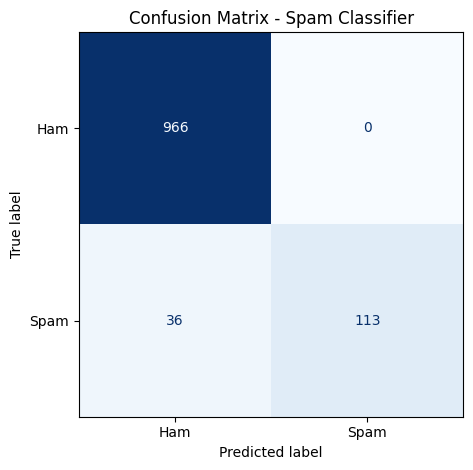

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Spam Classifier')
plt.tight_layout()
plt.show()

In [28]:
# Top words driving SPAM prediction
feature_names = tfidf.get_feature_names_out()
coef = model.coef_[0]

top_spam_idx = np.argsort(coef)[-15:][::-1]
top_ham_idx  = np.argsort(coef)[:15]

print("🔴 Top words indicating SPAM:")
for idx in top_spam_idx:
    print(f"  {feature_names[idx]:20s} → coef: {coef[idx]:.4f}")

print("\n🟢 Top words indicating HAM:")
for idx in top_ham_idx:
    print(f"  {feature_names[idx]:20s} → coef: {coef[idx]:.4f}")

🔴 Top words indicating SPAM:
  txt                  → coef: 5.1881
  claim                → coef: 3.6540
  stop                 → coef: 3.4414
  repli                → coef: 3.4019
  free                 → coef: 3.3988
  mobil                → coef: 3.2570
  servic               → coef: 3.2168
  text                 → coef: 3.1857
  call                 → coef: 3.1019
  prize                → coef: 2.7699
  win                  → coef: 2.6915
  urgent               → coef: 2.3695
  tone                 → coef: 2.2958
  nokia                → coef: 2.2502
  award                → coef: 2.1905

🟢 Top words indicating HAM:
  im                   → coef: -2.0343
  ltgt                 → coef: -1.9854
  ill                  → coef: -1.7823
  ok                   → coef: -1.6669
  later                → coef: -1.2931
  come                 → coef: -1.2832
  sorri                → coef: -1.2683
  home                 → coef: -1.2506
  sir                  → coef: -1.2491
  da                 

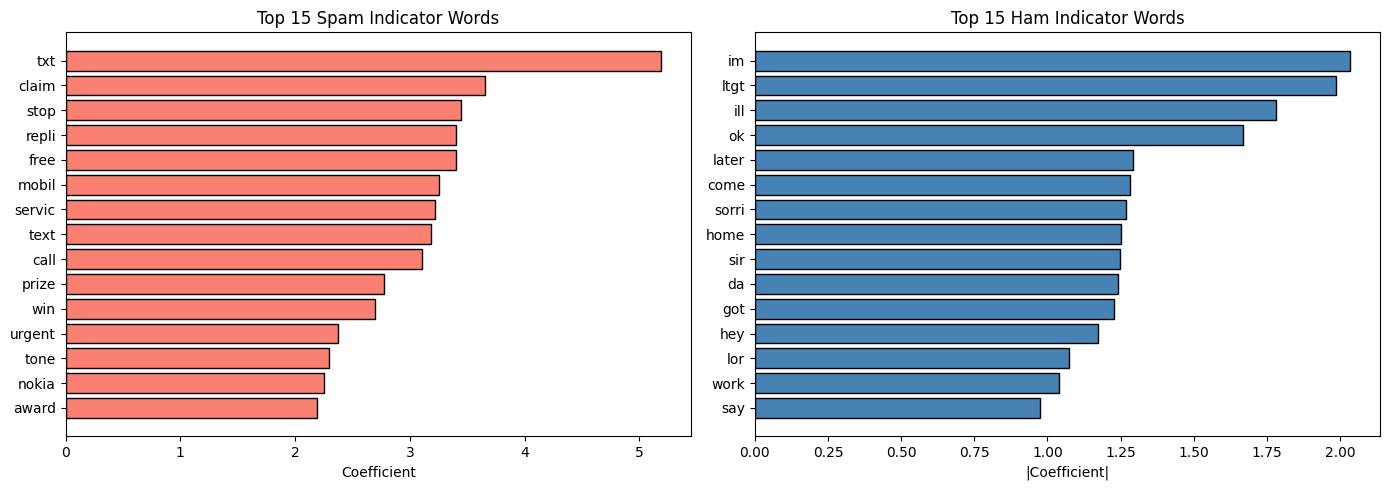

In [29]:
# Visualize top spam/ham words
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spam words
axes[0].barh([feature_names[i] for i in top_spam_idx], [coef[i] for i in top_spam_idx],
             color='salmon', edgecolor='black')
axes[0].set_title('Top 15 Spam Indicator Words')
axes[0].set_xlabel('Coefficient')
axes[0].invert_yaxis()

# Ham words
axes[1].barh([feature_names[i] for i in top_ham_idx], [abs(coef[i]) for i in top_ham_idx],
             color='steelblue', edgecolor='black')
axes[1].set_title('Top 15 Ham Indicator Words')
axes[1].set_xlabel('|Coefficient|')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 7: Test with Custom Messages

In [30]:
def predict_message(msg):
    cleaned = preprocess_text(msg)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = '🔴 SPAM' if pred == 1 else '🟢 HAM'
    print(f"Message : {msg}")
    print(f"Prediction : {label}")
    print(f"Confidence : Ham={prob[0]*100:.1f}% | Spam={prob[1]*100:.1f}%")
    print("-" * 60)

# Test messages
predict_message("Congratulations! You've won a FREE iPhone. Click here now!")
predict_message("Hey, are we meeting tomorrow for the project review?")
predict_message("URGENT: Your bank account has been compromised. Call now!")
predict_message("Can you please send me the notes from today's class?")

Message : Congratulations! You've won a FREE iPhone. Click here now!
Prediction : 🟢 HAM
Confidence : Ham=74.3% | Spam=25.7%
------------------------------------------------------------
Message : Hey, are we meeting tomorrow for the project review?
Prediction : 🟢 HAM
Confidence : Ham=96.9% | Spam=3.1%
------------------------------------------------------------
Message : URGENT: Your bank account has been compromised. Call now!
Prediction : 🔴 SPAM
Confidence : Ham=49.1% | Spam=50.9%
------------------------------------------------------------
Message : Can you please send me the notes from today's class?
Prediction : 🟢 HAM
Confidence : Ham=87.6% | Spam=12.4%
------------------------------------------------------------


## ✅ Summary

| Step | What we did |
|------|-------------|
| Dataset | SMS Spam Collection (5572 messages) |
| Cleaning | Lowercase, remove special chars |
| Tokenization | `word_tokenize` from NLTK |
| Stopword Removal | NLTK English stopwords |
| Stemming | PorterStemmer |
| Lemmatization | WordNetLemmatizer |
| Vectorization | TF-IDF (max 5000 features) |
| Model | Logistic Regression |
| Evaluation | Accuracy, Classification Report, Confusion Matrix |